In [ ]:
import scipy.stats as sp
import numpy as np
from scipy.stats import norm

S = 100
K = 100
T = 1
r = 0.05
sigma = 0.2

d1 = (np.log(S/K) + (r + sigma**2/2)*T)/(sigma * np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

call_price = S * norm.cdf(d1) - K * np.exp(-r*T)*norm.cdf(d2)
print(f'{call_price: .2f}')

 10.45


In [ ]:
put_price = K*np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
print(f'{put_price: .2f}')

if call_price - put_price == S-K*np.exp(-r*T):
  print('La Call-Put Parity est respectée.')
else:
  print('Call-Put Parity pas respectée' )

 5.57
La Call-Put Parity est respectée.


In [ ]:
delta_call = norm.cdf(d1)
print(f'{delta_call: .2f}')

delta_put = norm.cdf(d1) -1
print(f'{delta_put: .2f}')

gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
print(f'{gamma: .2f}')

vega = S * norm.pdf(d1) * np.sqrt(T)
print(f'{vega: .2f}')

theta_call = -(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T)) - r*K * np.exp(-r*T) * norm.cdf(d2)
print(f'{theta_call: .2f}')

theta_put = -(S * norm.pdf(d1) * sigma) / (2*np.sqrt(T)) + r*K * np.exp(-r*T)*norm.cdf(-d2)
print(f'{theta_put: .2f}')

rho_call = K * T * np.exp(-r*T)*norm.cdf(d2)
rho_put = -K * T * np.exp(-r*T)*norm.cdf(-d2)

print(f'{rho_call: .2f}')
print(f'{rho_put: .2f}')

 0.64
-0.36
 0.02
 37.52
-6.41
-1.66
 53.23
-41.89


[-3.1157359  -3.01573257 -2.91769021 -2.8215334  -2.72719098 -2.63459574
 -2.54368415 -2.45439606 -2.36667451 -2.28046548 -2.19571769 -2.11238243
 -2.03041338 -1.94976647 -1.87039972 -1.79227313 -1.71534854 -1.63958951
 -1.56496126 -1.49143052 -1.41896549 -1.3475357  -1.277112   -1.20766644
 -1.13917222 -1.07160362 -1.00493597 -0.93914555 -0.87420957 -0.81010613
 -0.74681414 -0.68431333 -0.62258415 -0.56160778 -0.50136609 -0.44184158
 -0.38301737 -0.32487718 -0.26740528 -0.21058649 -0.15440612 -0.09885
 -0.04390439  0.01044397  0.06420793  0.11739992  0.17003199  0.22211579
  0.27366264  0.32468349  0.37518897  0.42518939  0.47469474  0.52371474
  0.57225881  0.62033611  0.66795551  0.71512568  0.76185499  0.80815161
  0.8540235   0.89947835  0.9445237   0.98916686  1.03341493  1.07727486
  1.1207534   1.16385711  1.20659242  1.24896555  1.29098261  1.33264951
  1.37397206  1.4149559   1.45560653  1.49592933  1.53592954  1.57561229
  1.61498257  1.65404527  1.69280516  1.73126688  1.76

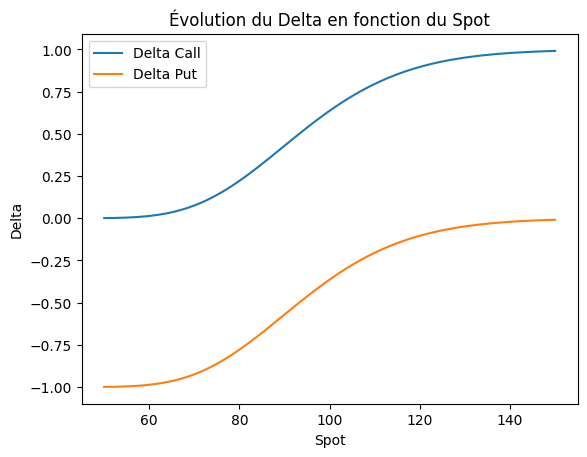

In [ ]:
s_range = np.linspace(50, 150, 100) #génere des niveaux ou des points régulièrement espacés sur un intervalle donné. Exemple: np.linspace(début, fin, nombre_de_points)
d1_range = (np.log(s_range/K) + (r + sigma**2/2)*T)/(sigma * np.sqrt(T))
print(d1_range)

delta_call_range = norm.cdf(d1_range)

import matplotlib.pyplot as plt
plt.plot(s_range, delta_call_range)
plt.xlabel('Spot')
plt.ylabel('Delta')
plt.title('Évolution du Delta en fonction du Spot')

delta_put_range = norm.cdf(d1) - 1
plt.plot(s_range, delta_put_range)
plt.xlabel('Spot')
plt.ylabel('Delta')
plt.title('Évolution du Delta en fonction du Spot')
plt.legend(['Delta Call', 'Delta Put'])
plt.show()

[0.00031109 0.00041433 0.00054344 0.00070248 0.0008956  0.00112688
 0.00140026 0.00171933 0.00208725 0.00250657 0.00297916 0.00350602
 0.00408727 0.00472205 0.00540847 0.00614364 0.00692366 0.00774367
 0.00859796 0.00948004 0.01038275 0.01129845 0.01221909 0.01313642
 0.01404213 0.01492799 0.015786   0.01660853 0.01738843 0.01811916
 0.01879483 0.01941032 0.01996131 0.02044431 0.02085667 0.0211966
 0.02146313 0.0216561  0.02177609 0.0218244  0.02180295 0.02171425
 0.02156133 0.02134764 0.02107698 0.02075346 0.0203814  0.01996526
 0.01950959 0.01901899 0.01849801 0.01795114 0.01738274 0.01679704
 0.01619808 0.01558967 0.01497543 0.01435871 0.01374262 0.01313
 0.01252344 0.01192525 0.01133752 0.01076204 0.01020041 0.00965397
 0.00912383 0.00861092 0.00811597 0.00763951 0.00718194 0.00674349
 0.00632424 0.00592419 0.00554318 0.00518099 0.00483731 0.00451175
 0.00420386 0.00391315 0.00363907 0.00338106 0.00313851 0.00291081
 0.00269732 0.00249743 0.00231048 0.00213585 0.00197291 0.00182105

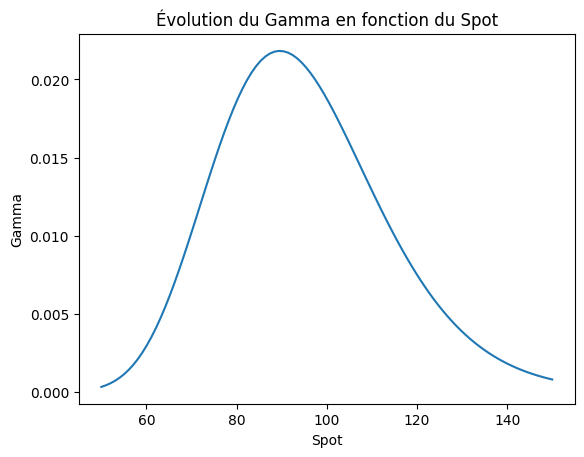

In [ ]:
s_range = np.linspace(50, 150, 100)
d1 = (np.log(s_range/K) + (r+sigma**2/2)*T)/(sigma * np.sqrt(T))

gamma_range = norm.pdf(d1) / (s_range * sigma * np.sqrt(T))
print(gamma_range)

import matplotlib.pyplot as plt
plt.plot(s_range, gamma_range)
plt.xlabel('Spot')
plt.ylabel('Gamma')
plt.title('Évolution du Gamma en fonction du Spot')
plt.show()

Text(0.5, 1.0, 'Évolution du Vega en fonction du Spot')

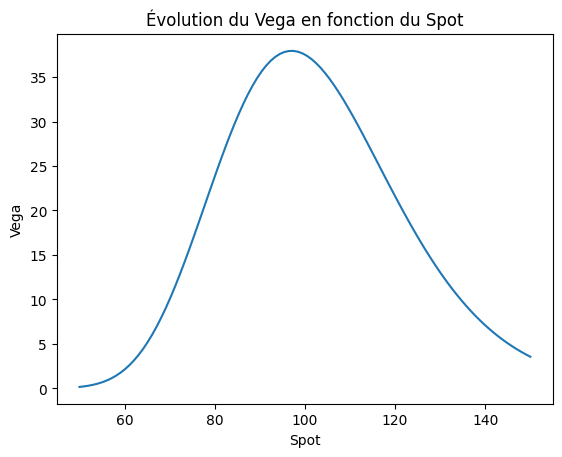

In [ ]:
d1_range = (np.log(s_range/K) + (r + sigma**2/2)*T)/(sigma * np.sqrt(T))
d2_range = d1_range - sigma*np.sqrt(T)
vega_range = s_range * norm.pdf(d1_range) * np.sqrt(T)
plt.plot(s_range, vega_range)
plt.xlabel('Spot')
plt.ylabel('Vega')
plt.title('Évolution du Vega en fonction du Spot')

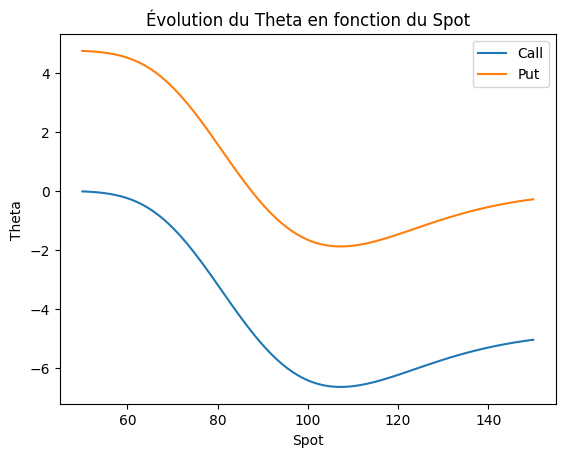

In [ ]:
d1_range = (np.log(s_range/K) + (r + sigma**2/2)*T)/(sigma * np.sqrt(T))
d2_range = d1_range - sigma*np.sqrt(T)
theta_call_range = -(s_range * norm.pdf(d1_range) * sigma) / (2*np.sqrt(T)) - r*K * np.exp(-r*T) * norm.cdf(d2_range)
plt.plot(s_range, theta_call_range)
plt.xlabel('Spot')
plt.ylabel('Theta')
plt.title('Évolution du Theta en fonction du Spot')

theta_put_range = -(s_range * norm.pdf(d1_range) * sigma) / (2*np.sqrt(T)) + r*K * np.exp(-r*T)*norm.cdf(-d2_range)
plt.plot(s_range, theta_put_range)
plt.xlabel('Spot')
plt.ylabel('Theta')
plt.legend(['Call', 'Put'])
plt.title('Évolution du Theta en fonction du Spot')
plt.show()

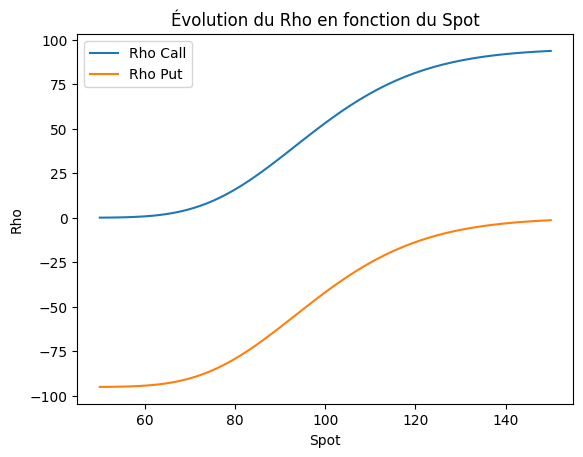

In [ ]:
d1_range = (np.log(s_range/K) + (r + sigma**2/2)*T)/(sigma * np.sqrt(T))
d2_range = d1_range - sigma*np.sqrt(T)

rho_call_range = K * T * np.exp(-r*T)*norm.cdf(d2_range)
rho_put_range = -K * T * np.exp(-r*T)*norm.cdf(-d2_range)

plt.plot(s_range, rho_call_range)
plt.xlabel('Spot')
plt.ylabel('Rho')
plt.title('Évolution du Rho en fonction du Spot')
plt.plot(s_range, rho_put_range)
plt.xlabel('Spot')
plt.ylabel('Rho')
plt.title('Évolution du Rho en fonction du Spot')
plt.legend(['Rho Call', 'Rho Put'])
plt.show()

In [ ]:
import yfinance as yf
ticker = "NVDA"
nvidia_data = yf.download(ticker, start="2025-05-18", end="2026-05-18")
print(nvidia_data.head())

log_returns=np.log(nvidia_data['Close']/nvidia_data['Close'].shift(1))
daily_vol = log_returns.std()
annual_vol = daily_vol * np.sqrt(252)
print(type(annual_vol))

annual_vol = float(annual_vol)
print(f'{annual_vol: .2f}')
print(f'{annual_vol: .2%}')


/tmp/ipykernel_2852/546568632.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvidia_data = yf.download(ticker, start="2025-05-18", end="2026-05-18")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            NVDA        NVDA        NVDA        NVDA       NVDA
Date                                                                 
2025-05-19  135.228943  135.528176  132.056935  132.056935  193154600
2025-05-20  134.041946  134.241440  132.286364  133.952161  161514200
2025-05-21  131.468445  137.054348  130.261482  132.725270  270608700
2025-05-22  132.495850  133.912276  131.219071  131.897353  187344000
2025-05-23  130.959717  132.346219  128.835085  129.672969  198821300
<class 'pandas.core.series.Series'>
 0.34
 33.89%



/tmp/ipykernel_2852/546568632.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  annual_vol = float(annual_vol)


 224.81
225
 0.15
-0.02
 16.43
 13.82


/tmp/ipykernel_2852/2657997234.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  nvidia_spot = float(nvidia_spot)


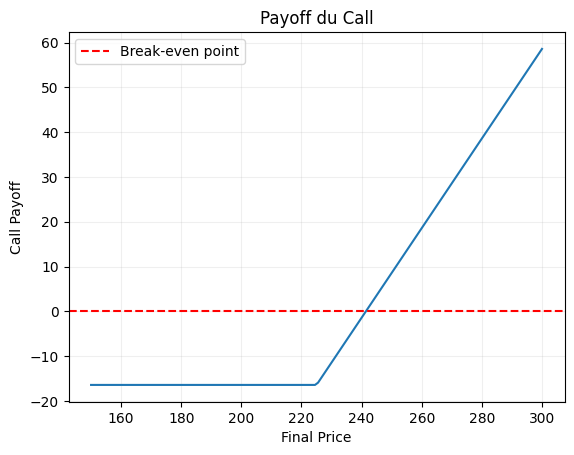

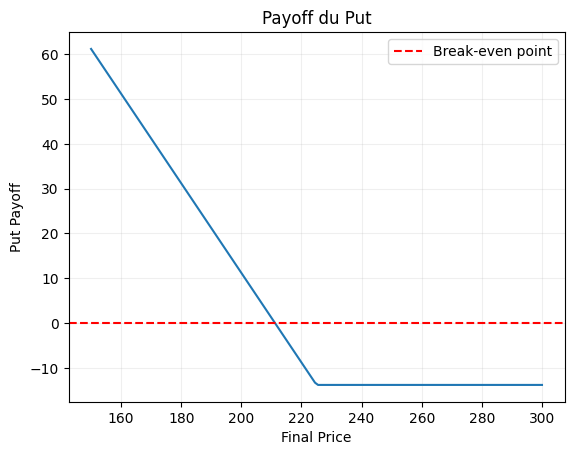

In [ ]:
nvidia_spot = nvidia_data['Close'].iloc[-1]
nvidia_spot = float(nvidia_spot)
print(f'{nvidia_spot: .2f}')

nvidia_strike = round(nvidia_spot / 5) *5
print(nvidia_strike)
T_nvidia = 0.25
r = 0.05
d1 = (np.log(nvidia_spot/nvidia_strike)+(r+annual_vol**2/2)*T_nvidia)/(annual_vol * np.sqrt(T_nvidia))
print(f'{d1: .2f}')
d2 = d1-annual_vol*np.sqrt(T_nvidia)
print(f'{d2: .2f}')

call_price = nvidia_spot * norm.cdf(d1) - nvidia_strike*np.exp(-r*T_nvidia)*norm.cdf(d2)
print(f'{call_price: .2f}')

put_price = nvidia_strike*np.exp(-r*T_nvidia) * norm.cdf(-d2) - nvidia_spot*norm.cdf(-d1)
print(f'{put_price: .2f}')

final_price = np.linspace(150, 300, 150)
payoff_call = np.maximum(final_price - nvidia_strike,0) - call_price
payoff_put = np.maximum(nvidia_strike - final_price,0) - put_price
plt.plot(final_price,payoff_call)
plt.xlabel("Final Price")
plt.ylabel("Call Payoff")
plt.axhline(y=0, color='red', linestyle='--', label = 'Break-even point')
plt.legend()
plt.title("Payoff du Call")
plt.grid(True, alpha = 0.2)
plt.show()

plt.plot(final_price, payoff_put)
plt.xlabel("Final Price")
plt.ylabel("Put Payoff")
plt.axhline(y=0, color='red', linestyle='--', label = 'Break-even point')
plt.legend()
plt.title("Payoff du Put")
plt.grid(True, alpha = 0.2)
plt.show()